In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Pengaturan visualisasi grafik
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 100,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

np.random.seed(42)
tf.random.set_seed(42)
print("Setup Final Evaluation Selesai!")

2026-06-11 05:01:38.432740: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781154098.800017      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781154098.904116      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781154099.800501      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781154099.800593      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781154099.800597      16 computation_placer.cc:177] computation placer alr

Setup Final Evaluation Selesai!


In [ ]:
# --- 1. LOAD DATA DARI NOTEBOOK 1 ---

path_nb1 = '/kaggle/input/notebooks/fauzanrasendriya/01-data-preprocessing-eda/opstat_1/'

df_train = pd.read_csv(path_nb1 + 'train.csv', parse_dates=['Tanggal'], index_col='Tanggal')
df_val   = pd.read_csv(path_nb1 + 'val.csv', parse_dates=['Tanggal'], index_col='Tanggal')
df_test  = pd.read_csv(path_nb1 + 'test.csv', parse_dates=['Tanggal'], index_col='Tanggal')

# Gabungkan Train dan Val sebagai data historis untuk Cross Validation & Final Training
df_train_val = pd.concat([df_train, df_val])
df_full = pd.concat([df_train_val, df_test])

# --- 2. FIT SCALER PADA DATA LATIH GABUNGAN ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train_val = scaler.fit_transform(df_train_val[['Y']].values) 

# Skala untuk data test penuh
scaled_full = scaler.transform(df_full[['Y']].values)
print("Data dan Scaler siap!")

Data dan Scaler siap!


In [ ]:
path_cpso = '/kaggle/input/notebooks/fauzanrasendriya/03-pso-sliding-window/outputs/pso-sliding-window-results.json'
path_rs   = '/kaggle/input/notebooks/fauzanrasendriya/02-random-search-sliding-window/outputs/random-search-sliding-window-results.json'

with open(path_cpso, 'r') as f: best_hp_cpso = json.load(f)
with open(path_rs, 'r') as f: best_hp_rs = json.load(f)

print("Hyperparameter CPSO Sukses Dimuat:", best_hp_cpso)
print("Hyperparameter Random Search Sukses Dimuat:", best_hp_rs)

Hyperparameter CPSO Sukses Dimuat: {'seq_len': 29, 'hidden_size': 151, 'num_layers': 1, 'lr': 0.008513645498481031, 'dropout': 0.09459040576607597, 'batch_size': 19, 'epochs': 87}
Hyperparameter Random Search Sukses Dimuat: {'seq_len': 25, 'hidden_size': 94, 'num_layers': 1, 'lr': 0.005396353482725237, 'dropout': 0.06302731382395105, 'batch_size': 34, 'epochs': 93}


In [4]:
def create_sequences(dataset, seq_len):
    X, y = [], []
    for i in range(len(dataset) - seq_len):
        X.append(dataset[i:(i + seq_len), 0])
        y.append(dataset[i + seq_len, 0])
    return np.array(X), np.array(y)

def build_lstm(hp):
    model = Sequential()
    model.add(LSTM(hp['hidden_size'], return_sequences=(hp['num_layers'] > 1), input_shape=(hp['seq_len'], 1)))
    model.add(Dropout(hp['dropout']))
    for i in range(1, hp['num_layers']):
        model.add(LSTM(hp['hidden_size'], return_sequences=(i < hp['num_layers'] - 1)))
        model.add(Dropout(hp['dropout']))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=hp['lr']), loss='mse')
    return model

def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'RMSE (IDR)': round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAE (IDR)': round(mean_absolute_error(y_true, y_pred), 2),
        'MAPE (%)': round(mean_absolute_percentage_error(y_true, y_pred) * 100, 3),
        'R-Squared': round(r2_score(y_true, y_pred), 4)
    }

def evaluate_pipeline(hp, model_name):
    print(f"\n=======================================================")
    print(f"MEMPROSES PIPELINE UNTUK: {model_name}")
    print(f"=======================================================")
    seq_len = hp['seq_len']
    
    # -----------------------------------------------------------------
    # FASE 1: REKREASI SLIDING WINDOW CV (UNTUK TABEL VALIDASI ASLI)
    # -----------------------------------------------------------------
    print("-> Fase 1: Merekonstruksi Sliding Window Cross Validation...")
    X_cv, y_cv = create_sequences(scaled_train_val, seq_len)
    X_cv = X_cv.reshape(X_cv.shape[0], X_cv.shape[1], 1)
    
    # Setup generator sliding window yang sama persis dengan Notebook 2 & 3
    tscv = TimeSeriesSplit(n_splits=3, max_train_size=500)
    
    cv_rmse, cv_mae, cv_mape, cv_r2 = [], [], [], []
    
    for fold, (train_index, test_index) in enumerate(tscv.split(X_cv)):
        X_train_fold, X_val_fold = X_cv[train_index], X_cv[test_index]
        y_train_fold, y_val_fold = y_cv[train_index], y_cv[test_index]
        
        # Latih model fold
        model_fold = build_lstm(hp)
        model_fold.fit(X_train_fold, y_train_fold, batch_size=hp['batch_size'], epochs=hp['epochs'], verbose=0)
        
        # Prediksi dan inverse transform
        preds_fold_scaled = model_fold.predict(X_val_fold, verbose=0)
        preds_fold_asli = scaler.inverse_transform(preds_fold_scaled)
        y_val_fold_asli = scaler.inverse_transform(y_val_fold.reshape(-1, 1))
        
        # Hitung metrik per fold
        cv_rmse.append(np.sqrt(mean_squared_error(y_val_fold_asli, preds_fold_asli)))
        cv_mae.append(mean_absolute_error(y_val_fold_asli, preds_fold_asli))
        cv_mape.append(mean_absolute_percentage_error(y_val_fold_asli, preds_fold_asli) * 100)
        cv_r2.append(r2_score(y_val_fold_asli, preds_fold_asli))
        
    # Ambil rata-rata performa CV dalam Rupiah
    metrics_val = {
        'Model': model_name,
        'RMSE (IDR)': round(np.mean(cv_rmse), 2),
        'MAE (IDR)': round(np.mean(cv_mae), 2),
        'MAPE (%)': round(np.mean(cv_mape), 3),
        'R-Squared': round(np.mean(cv_r2), 4)
    }
    
    # -----------------------------------------------------------------
    # FASE 2: FINAL TRAINING & TESTING (UNTUK TABEL DATA TEST FINAL)
    # -----------------------------------------------------------------
    print("-> Fase 2: Melatih Model Secara Penuh & Menguji Data Test...")
    X_train_full, y_train_full = create_sequences(scaled_train_val, seq_len)
    X_train_full = X_train_full.reshape(X_train_full.shape[0], X_train_full.shape[1], 1)
    
    # Siapkan data test dengan mempertahankan lag agar tidak ada data awal test yang hilang
    start_test_idx = len(df_train_val) - seq_len
    scaled_test_prep = scaled_full[start_test_idx:]
    X_test, y_test_scaled = create_sequences(scaled_test_prep, seq_len)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    
    # Latih model final
    model_final = build_lstm(hp)
    model_final.fit(X_train_full, y_train_full, batch_size=hp['batch_size'], epochs=hp['epochs'], verbose=0)
    
    # Prediksi data test
    preds_test_scaled = model_final.predict(X_test, verbose=0)
    preds_test_asli = scaler.inverse_transform(preds_test_scaled)
    y_test_asli = scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
    
    # Hitung metrik final data test
    metrics_test = calculate_metrics(y_test_asli, preds_test_asli, model_name)
    
    return metrics_val, metrics_test, preds_test_asli, y_test_asli

In [5]:
# Jalankan seluruh rangkaian kalkulasi untuk kedua model
val_cpso, test_cpso, preds_cpso, y_test_actual = evaluate_pipeline(best_hp_cpso, "LSTM + CPSO")
val_rs, test_rs, preds_rs, _ = evaluate_pipeline(best_hp_rs, "LSTM + Random Search")

# --- OUTPUT TABEL 1: VALIDASI (REKREASI CV) ---
df_val_table = pd.DataFrame([val_cpso, val_rs])
print("\n" + "="*80)
print("TABEL 1: RATA-RATA METRIK VALIDASI (CROSS VALIDATION - SKALA ASLI RUPIAH)")
print("="*80)
display(df_val_table)

# --- OUTPUT TABEL 2: FINAL TEST MASA DEPAN ---
df_test_table = pd.DataFrame([test_cpso, test_rs])
print("\n" + "="*80)
print("TABEL 2: METRIK EVALUASI FINAL PADA DATA TEST (SKALA ASLI RUPIAH)")
print("="*80)
display(df_test_table)


MEMPROSES PIPELINE UNTUK: LSTM + CPSO
-> Fase 1: Merekonstruksi Sliding Window Cross Validation...


2026-06-11 05:01:57.837614: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the mod

-> Fase 2: Melatih Model Secara Penuh & Menguji Data Test...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



MEMPROSES PIPELINE UNTUK: LSTM + Random Search
-> Fase 1: Merekonstruksi Sliding Window Cross Validation...


...

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



TABEL 1: RATA-RATA METRIK VALIDASI (CROSS VALIDATION - SKALA ASLI RUPIAH)


,Model,RMSE (IDR),MAE (IDR),MAPE (%),R-Squared
0,LSTM + CPSO,74.53,56.88,0.379,0.9706
1,LSTM + Random Search,100.79,80.54,0.531,0.9333



TABEL 2: METRIK EVALUASI FINAL PADA DATA TEST (SKALA ASLI RUPIAH)


,Model,RMSE (IDR),MAE (IDR),MAPE (%),R-Squared
0,LSTM + CPSO,69.25,60.14,0.366,0.9102
1,LSTM + Random Search,89.34,82.44,0.501,0.8505


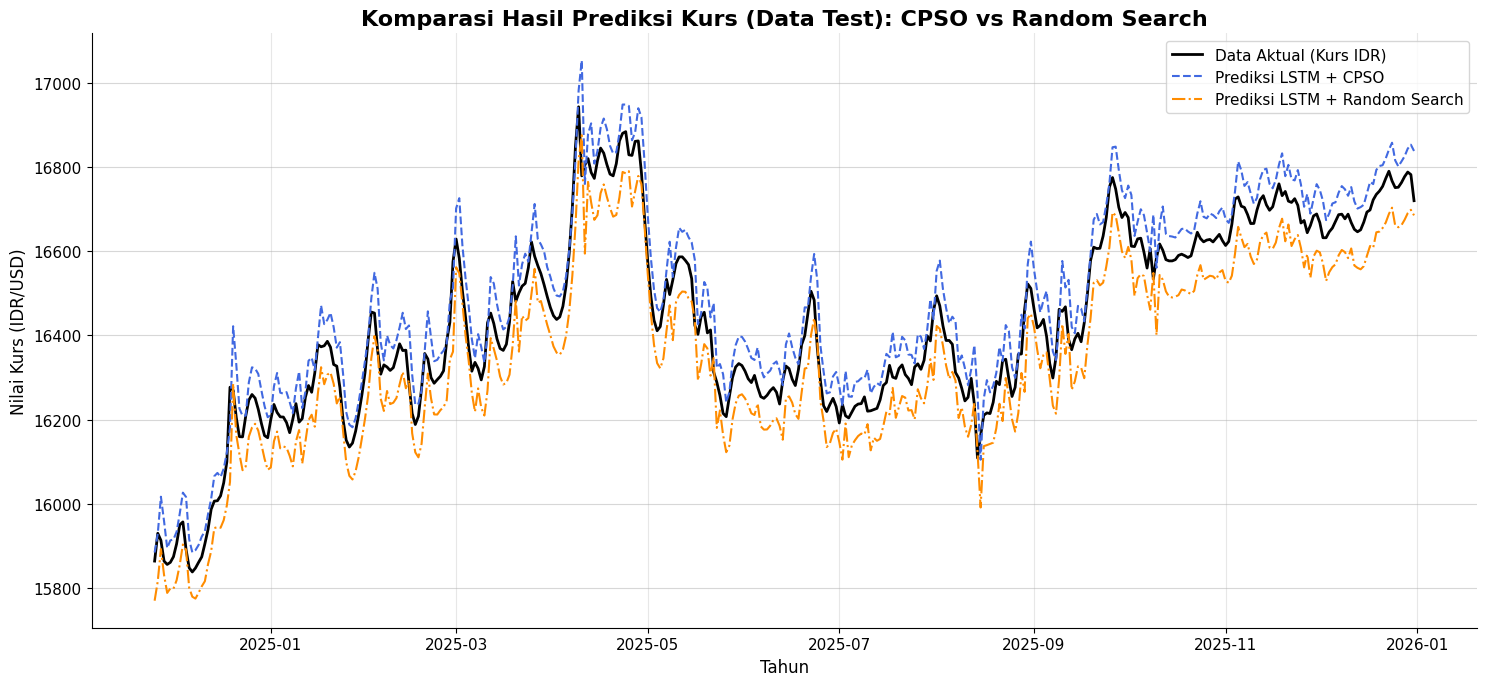

In [6]:
# Menyatukan data aktual dan prediksi ke dalam DataFrame untuk grafik
plot_df = pd.DataFrame(index=df_test.index)
plot_df['Aktual'] = y_test_actual
plot_df['Prediksi CPSO'] = preds_cpso
plot_df['Prediksi Random Search'] = preds_rs

# Plotting Grafik
plt.figure(figsize=(15, 7))
plt.plot(plot_df.index, plot_df['Aktual'], label='Data Aktual (Kurs IDR)', color='black', linewidth=2)
plt.plot(plot_df.index, plot_df['Prediksi CPSO'], label='Prediksi LSTM + CPSO', color='royalblue', linewidth=1.5, linestyle='--')
plt.plot(plot_df.index, plot_df['Prediksi Random Search'], label='Prediksi LSTM + Random Search', color='darkorange', linewidth=1.5, linestyle='-.')

plt.title('Komparasi Hasil Prediksi Kurs (Data Test): CPSO vs Random Search', fontsize=16, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Nilai Kurs (IDR/USD)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()